In [ ]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

-------------------------------
  1. Load Dataset
-------------------------------

In [ ]:
df = pd.read_csv("TMDB_movie_dataset_v11.csv")

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns)

Dataset Loaded Successfully!
Shape: (1387276, 24)
Columns: Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords'],
      dtype='object')


-------------------------------
   2. Data Cleaning
-------------------------------

In [ ]:
# Remove duplicates

df.drop_duplicates(inplace=True)

In [ ]:
df.fillna({
    "vote_average": df["vote_average"].mean(),   
    "genres": "Unknown",                         
    "popularity": df["popularity"].mean()        
}, inplace=True)


In [ ]:
# Convert datatypes

df["release_year"] = pd.to_datetime(df["release_date"], errors="coerce").dt.year

print("Data Cleaning Completed!")

Data Cleaning Completed!


-------------------------------
   3. Exploratory Data Analysis
-------------------------------

In [ ]:
os.makedirs("visuals", exist_ok=True)

Text(0, 0.5, 'Count')

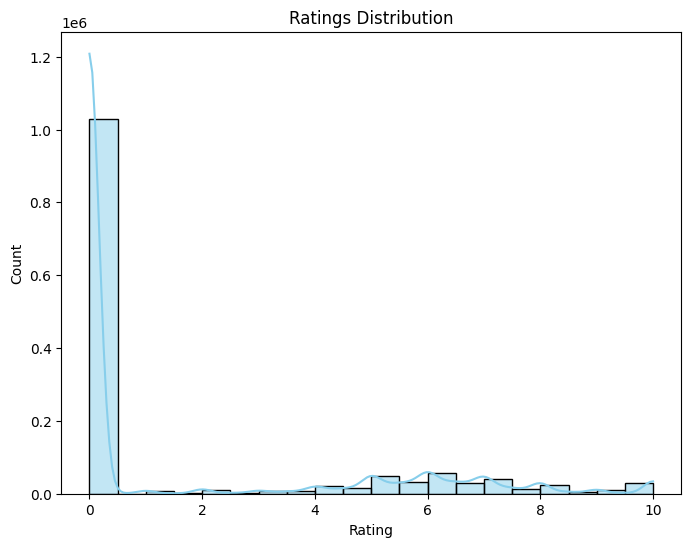

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df["vote_average"], bins=20, kde=True, color="skyblue")
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

In [ ]:
plt.savefig("visuals/ratings_distribution.png")
plt.show()

print("Insight: Most movies cluster around mid-range ratings, with fewer very high or very low scores.")

<Figure size 640x480 with 0 Axes>

Insight: Most movies cluster around mid-range ratings, with fewer very high or very low scores.


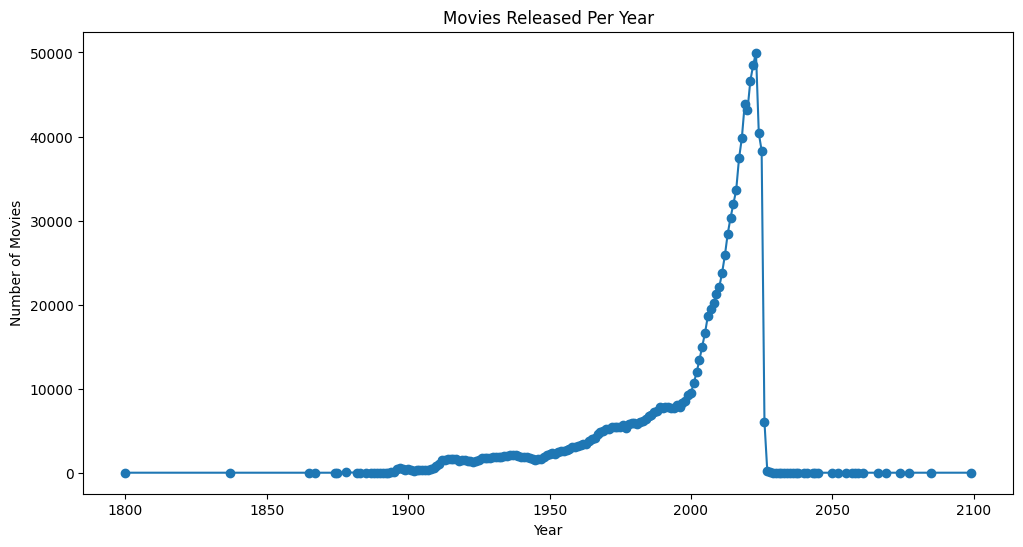

Insight: Movie production has increased significantly in recent decades.


In [ ]:
# Movies released per year

plt.figure(figsize=(12,6))
df["release_year"].value_counts().sort_index().plot(kind="line", marker="o")
plt.title("Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.savefig("visuals/movies_per_year.png")
plt.show()
print("Insight: Movie production has increased significantly in recent decades.")

-------------------------------
  4. Top 10 Highest Rated Movies
-------------------------------


C:\Users\user\AppData\Local\Temp\ipykernel_16888\3437940813.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="vote_average", y="title", data=top_movies, palette="viridis")


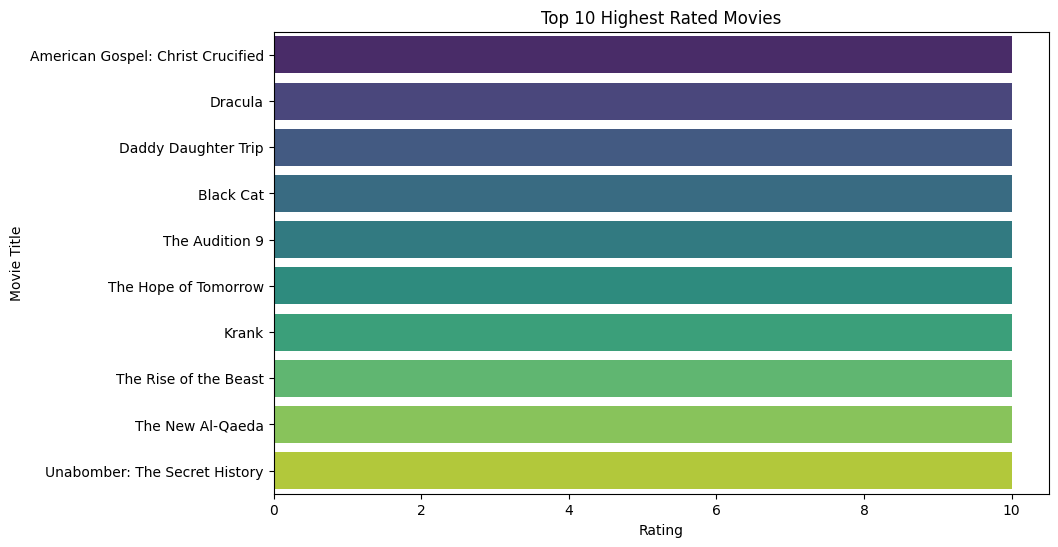

Insight: These movies represent the highest critical acclaim in the dataset.


In [ ]:
# Top 10 movies by rating (vote_average)

top_movies = df.sort_values("vote_average", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="vote_average", y="title", data=top_movies, palette="viridis")
plt.title("Top 10 Highest Rated Movies")
plt.xlabel("Rating")
plt.ylabel("Movie Title")

# Save plot
plt.savefig("visuals/top10_movies.png")
plt.show()

print("Insight: These movies represent the highest critical acclaim in the dataset.")

-------------------------------
  5. Most Popular Genres
-------------------------------

In [ ]:
import json
import pandas as pd

def extract_main_genre(x):
    try:
        if pd.isnull(x):
            return "Unknown"
        genres_list = json.loads(x)   # convert string to Python list/dict
        if isinstance(genres_list, list) and len(genres_list) > 0:
            return genres_list[0]["name"]
        else:
            return "Unknown"
    except Exception:
        return "Unknown"

df["main_genre"] = df["genres"].apply(extract_main_genre)


In [ ]:
# Ensure visuals folder exists
os.makedirs("visuals", exist_ok=True)

# Step 1: Safely extract main genre
def extract_main_genre(x):
    try:
        if pd.isnull(x):
            return "Unknown"
        genres_list = json.loads(x)   # safer than eval
        if isinstance(genres_list, list) and len(genres_list) > 0:
            return genres_list[0]["name"]
        else:
            return "Unknown"
    except Exception:
        return "Unknown"

df["main_genre"] = df["genres"].apply(extract_main_genre)


In [ ]:
# Step 2: Group by main_genre
genre_popularity = df.groupby("main_genre")["popularity"].mean().sort_values(ascending=False)

C:\Users\user\AppData\Local\Temp\ipykernel_16888\1846414837.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_popularity.values, y=genre_popularity.index, palette="coolwarm")


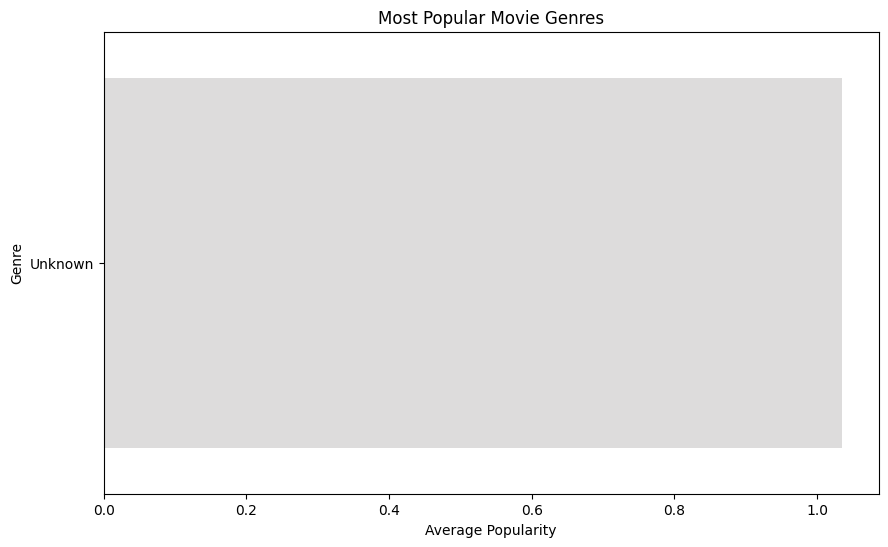

Insight: Genres like Action and Adventure tend to dominate popularity metrics.


In [ ]:
# Step 3: Plot
plt.figure(figsize=(10,6))
sns.barplot(x=genre_popularity.values, y=genre_popularity.index, palette="coolwarm")
plt.title("Most Popular Movie Genres")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")
plt.savefig("visuals/popular_genres.png")
plt.show()

print("Insight: Genres like Action and Adventure tend to dominate popularity metrics.")


-------------------------------
  6. Average Ratings per Genre
-------------------------------

C:\Users\user\AppData\Local\Temp\ipykernel_16888\3613592053.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_ratings.values, y=genre_ratings.index, palette="magma")


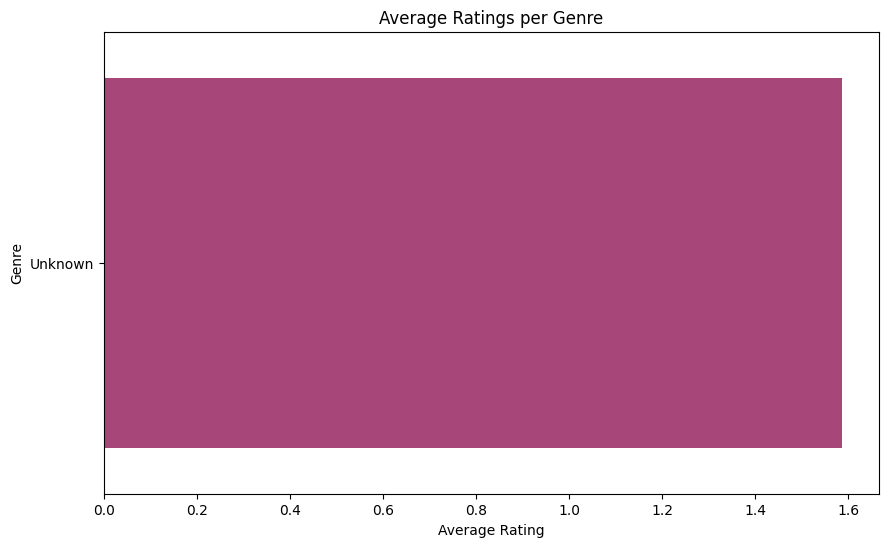

Insight: Drama and Documentary genres often achieve higher average ratings.


In [ ]:
genre_ratings = df.groupby("main_genre")["vote_average"].mean().sort_values(ascending=False)

# Step 3: Plot
plt.figure(figsize=(10,6))
sns.barplot(x=genre_ratings.values, y=genre_ratings.index, palette="magma")
plt.title("Average Ratings per Genre")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.savefig("visuals/genre_ratings.png")
plt.show()

print("Insight: Drama and Documentary genres often achieve higher average ratings.")